In [2]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb -q
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.ensemble import HistGradientBoostingClassifier
from google.colab import drive
import pickle
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [3]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)


In [4]:
# Celda 3 — Función de evaluación (5-Fold CV, scaler por fold)
def evaluar_modelo_cv(model, X_train, y_train, X_val, y_val, X_test, y_test,
                      nombre, k=5):
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])
        model.fit(X_tr_fold, y_train[tr_idx])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    model.fit(X_train_sc, y_train)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds), "AUC_CV_std": np.std(auc_folds),
        "F1_CV_mean": np.mean(f1_folds),   "F1_CV_std": np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds), "Acc_CV_std": np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds), "Precision_CV_std": np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds), "Recall_CV_std": np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler, "_model": model,
    }


def tabla_resultados(resultados_lista):
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando HistGradientBoosting...
  lr=0.05, leaves=31  , l2=0.0: AUC val = 0.8195  (stop @ iter 500)
  lr=0.05, leaves=31  , l2=0.5: AUC val = 0.8192  (stop @ iter 500)
  lr=0.05, leaves=63  , l2=0.0: AUC val = 0.8221  (stop @ iter 387)
  lr=0.05, leaves=63  , l2=0.5: AUC val = 0.8210  (stop @ iter 276)
  lr=0.05, leaves=127 , l2=0.0: AUC val = 0.8242  (stop @ iter 247)
  lr=0.05, leaves=127 , l2=0.5: AUC val = 0.8242  (stop @ iter 286)
  lr=0.05, leaves=None, l2=0.0: AUC val = 0.8267  (stop @ iter 427)
  lr=0.05, leaves=None, l2=0.5: AUC val = 0.8236  (stop @ iter 250)
  lr=0.10, leaves=31  , l2=0.0: AUC val = 0.8192  (stop @ iter 262)
  lr=0.10, leaves=31  , l2=0.5: AUC val = 0.8210  (stop @ iter 375)
  lr=0.10, leaves=63  , l2=0.0: AUC val = 0.8213  (stop @ iter 179)
  lr=0.10, leaves=63  , l2=0.5: AUC val = 0.8227  (stop @ iter 250)
  lr=0.10, leaves=127 , l2=0.0: AUC val = 0.8229  (stop @ iter 161)
  lr=0.10, leaves=127 , l2=0.5: AUC val = 0.8229  (stop @ iter 104)
  lr=0.10, le

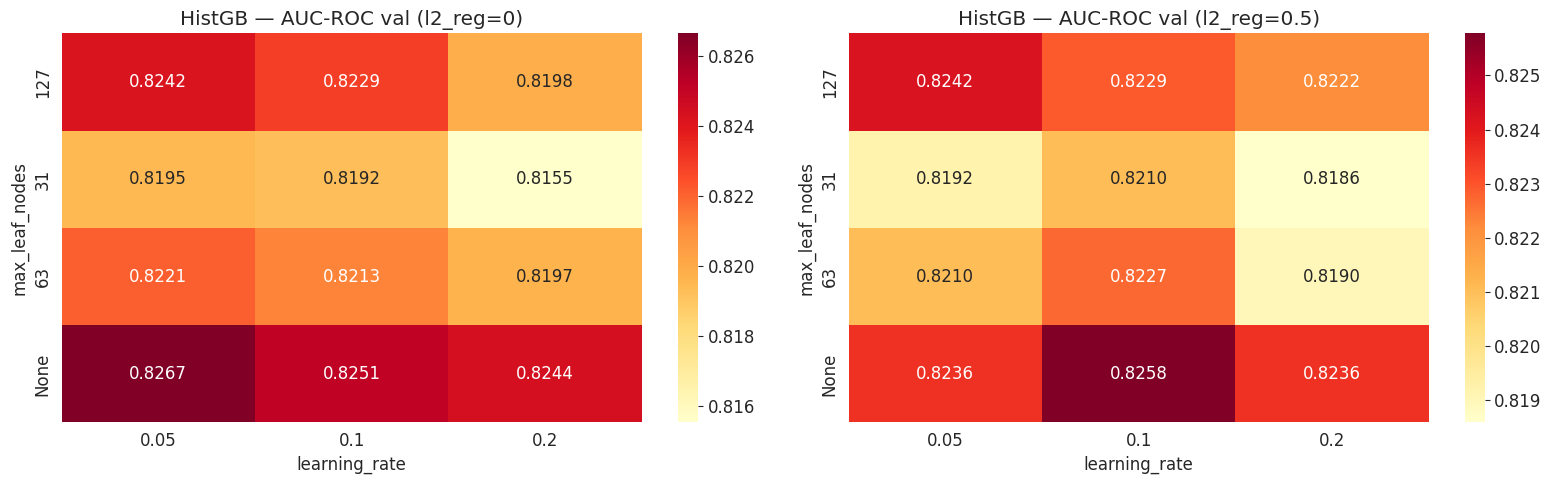


Top 5 configuraciones:
 learning_rate max_leaf_nodes  l2_reg      AUC  n_iter
          0.05           None     0.0 0.826657     427
          0.10           None     0.5 0.825777     500
          0.10           None     0.0 0.825148     280
          0.20           None     0.0 0.824405     285
          0.05            127     0.5 0.824232     286

Mejores parámetros HistGB: {'learning_rate': 0.05, 'max_leaf_nodes': None, 'l2_regularization': 0}


AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▃▃▅▄▆▆█▆▃▄▅▆▆▆▇▇▁▃▄▃▄▅▇▆█
Acc_test,▁
F1_test,▁
l2_reg,▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█
lr,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃████████
n_iter,██▆▄▄▅▇▄▄▆▃▄▃▂▅█▂▃▂▁▁▂▅█
AUC_CV_2std,0.00314
AUC_CV_mean,0.82137


In [5]:
# Celda 4 — HistGradientBoosting (gradient boosting con histogramas)
# NOTA: Basado en árboles → no requiere scaling.
# max_leaf_nodes controla complejidad del árbol (más efectivo que max_depth).
# l2_regularization ayuda a prevenir overfitting en ensembles grandes.
# Grinsztajn et al. (2022): HistGB ~0.883 AUC en HIGGS.

nombre_modelo = "HistGradientBoosting"

wandb.init(project="higgs-boson", name="HistGB", config={
    "learning_rate_grid": [0.05, 0.1, 0.2],
    "max_leaf_nodes_grid": [31, 63, 127, None],
    "l2_regularization_grid": [0, 0.5],
    "max_iter": 500,
    "early_stopping": True,
})
print(f"Entrenando {nombre_modelo}...")

param_grid_hgb = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_leaf_nodes": [31, 63, 127, None],
    "l2_regularization": [0, 0.5],
}
best_auc_hgb = 0
best_params_hgb = {}
hgb_results_grid = []

for lr in param_grid_hgb["learning_rate"]:
    for leaves in param_grid_hgb["max_leaf_nodes"]:
        for l2 in param_grid_hgb["l2_regularization"]:
            hgb = HistGradientBoostingClassifier(
                learning_rate=lr, max_leaf_nodes=leaves,
                l2_regularization=l2,
                max_iter=500, early_stopping=True,
                validation_fraction=0.1,
                scoring="roc_auc", random_state=42
            )
            hgb.fit(X_train, y_train)
            auc = roc_auc_score(y_val, hgb.predict_proba(X_val)[:, 1])
            n_iter = hgb.n_iter_
            hgb_results_grid.append({
                "learning_rate": lr, "max_leaf_nodes": str(leaves),
                "l2_reg": l2, "AUC": auc, "n_iter": n_iter
            })
            wandb.log({"lr": lr, "max_leaf_nodes": str(leaves), "l2_reg": l2,
                        "AUC_val": auc, "n_iter": n_iter})
            print(f"  lr={lr:.2f}, leaves={str(leaves):4s}, l2={l2:.1f}: AUC val = {auc:.4f}  (stop @ iter {n_iter})")
            if auc > best_auc_hgb:
                best_auc_hgb = auc
                best_params_hgb = {"learning_rate": lr, "max_leaf_nodes": leaves,
                                   "l2_regularization": l2}

df_hgb_grid = pd.DataFrame(hgb_results_grid)

# Dos heatmaps: uno por cada valor de l2_regularization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, l2_val in zip(axes, [0, 0.5]):
    subset = df_hgb_grid[df_hgb_grid["l2_reg"] == l2_val]
    pivot = subset.pivot(index="max_leaf_nodes", columns="learning_rate", values="AUC")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"HistGB — AUC-ROC val (l2_reg={l2_val})")
    ax.set_xlabel("learning_rate")
    ax.set_ylabel("max_leaf_nodes")
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_histgb_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen ordenada por AUC
print("\nTop 5 configuraciones:")
print(df_hgb_grid.sort_values("AUC", ascending=False).head(5)
      [["learning_rate", "max_leaf_nodes", "l2_reg", "AUC", "n_iter"]].to_string(index=False))

print(f"\nMejores parámetros HistGB: {best_params_hgb}")
hgb_best = HistGradientBoostingClassifier(
    **best_params_hgb, max_iter=500,
    early_stopping=True, validation_fraction=0.1,
    scoring="roc_auc", random_state=42
)
result = evaluar_modelo_cv(hgb_best, X_train, y_train, X_val, y_val,
                            X_test, y_test, nombre_modelo)

# Log final metrics to wandb
wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()

In [6]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

# Guardar CSV para ensamblaje final
safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

# Guardar modelo pickle
with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

                     AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                            
HistGradientBoosting    0.821 ± 0.003   0.826    0.825   0.760    0.744          0.754       0.767

Artefactos guardados: resultado_HistGradientBoosting.csv + modelo_HistGradientBoosting.pkl
